# Social Media-Based Trend Prediction
### Predicting Viral Content on Social Media Platforms



## 1. Setup and Data Loading

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, precision_score,
                              recall_score, confusion_matrix, RocCurveDisplay, classification_report)
from xgboost import XGBClassifier
import shap

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('social_media_viral_content_dataset.csv')
print(df.shape)
df.head()

(2000, 15)


,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0
3,SM_100003,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1


In [ ]:
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          2000 non-null   object 
 1   platform         2000 non-null   object 
 2   content_type     2000 non-null   object 
 3   topic            2000 non-null   object 
 4   language         2000 non-null   object 
 5   region           2000 non-null   object 
 6   post_datetime    2000 non-null   object 
 7   hashtags         2000 non-null   object 
 8   views            2000 non-null   int64  
 9   likes            2000 non-null   int64  
 10  comments         2000 non-null   int64  
 11  shares           2000 non-null   int64  
 12  engagement_rate  2000 non-null   float64
 13  sentiment_score  2000 non-null   float64
 14  is_viral         2000 non-null   int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 234.5+ KB

Missing values per column:
post_id            

## 2. Exploratory Data Analysis

In [ ]:
for col in ['platform','content_type','topic','language','region']:
    print(df[col].value_counts(), '\n')
print(df['is_viral'].value_counts(normalize=True))

platform
Instagram         539
YouTube Shorts    499
X                 485
TikTok            477
Name: count, dtype: int64 

content_type
carousel    528
image       512
text        488
video       472
Name: count, dtype: int64 

topic
Education        347
Entertainment    345
Politics         332
Technology       331
Sports           330
Lifestyle        315
Name: count, dtype: int64 

language
en    420
ur    405
fr    404
hi    392
es    379
Name: count, dtype: int64 

region
US          428
India       406
Brazil      402
UK          385
Pakistan    379
Name: count, dtype: int64 

is_viral
1    0.699
0    0.301
Name: proportion, dtype: float64


In [ ]:
df[['views','likes','comments','shares','engagement_rate','sentiment_score']].describe()

,views,likes,comments,shares,engagement_rate,sentiment_score
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.284860e+06,245329.244000,24786.929000,49936.981500,0.157852,-0.000566
std,3.246193e+06,145032.423582,14433.288364,29012.818697,0.535457,0.574911
min,4.380000e+03,292.000000,14.000000,127.000000,0.035700,-1.000000
25%,1.652742e+06,118903.750000,12337.750000,25698.750000,0.057975,-0.507000
50%,3.469408e+06,239831.000000,24519.500000,50212.000000,0.084500,0.001000
75%,6.348078e+06,372323.500000,37116.250000,75433.000000,0.142525,0.495250
max,1.437179e+07,499983.000000,49989.000000,99977.000000,12.573200,0.999000


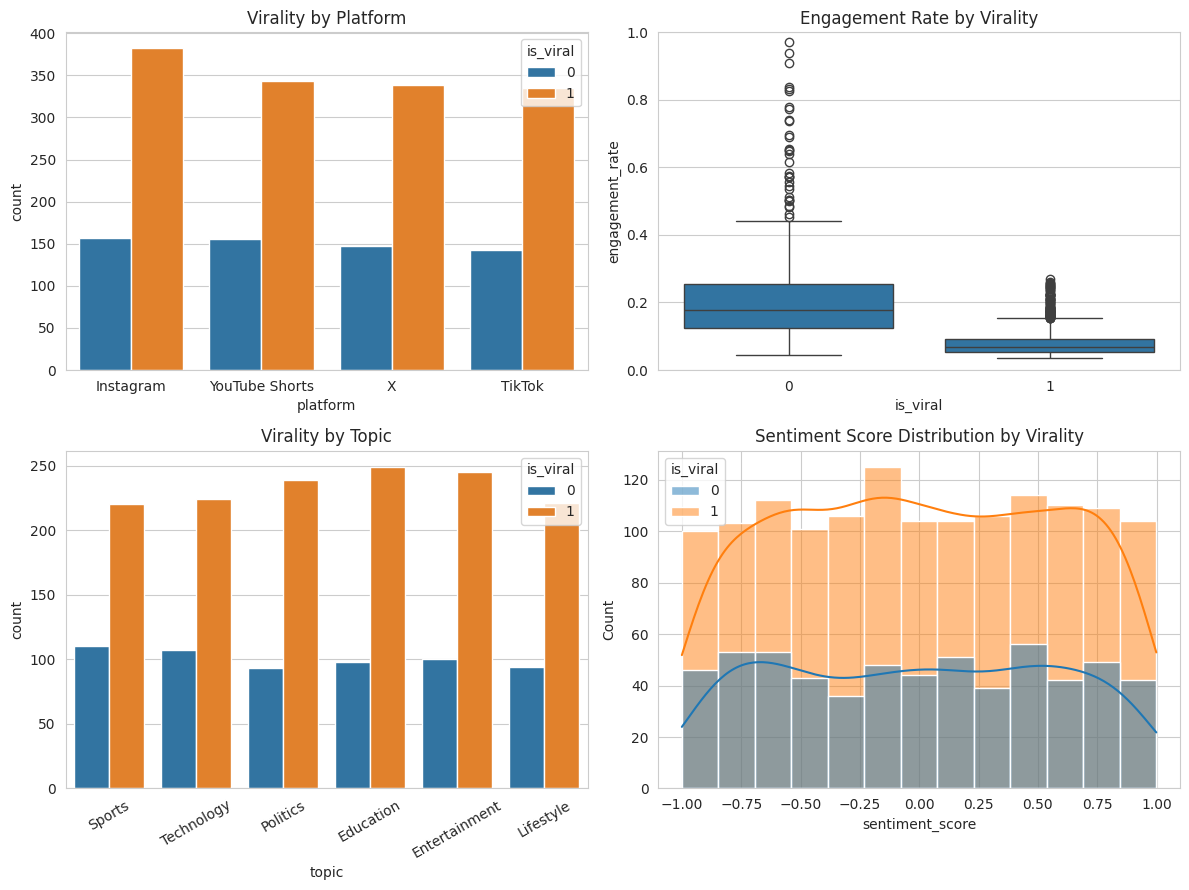

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,9))
sns.countplot(data=df, x='platform', hue='is_viral', ax=axes[0,0])
axes[0,0].set_title('Virality by Platform')
sns.boxplot(data=df, x='is_viral', y='engagement_rate', ax=axes[0,1])
axes[0,1].set_ylim(0,1)
axes[0,1].set_title('Engagement Rate by Virality')
sns.countplot(data=df, x='topic', hue='is_viral', ax=axes[1,0])
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].set_title('Virality by Topic')
sns.histplot(data=df, x='sentiment_score', hue='is_viral', kde=True, ax=axes[1,1])
axes[1,1].set_title('Sentiment Score Distribution by Virality')
plt.tight_layout()
plt.show()

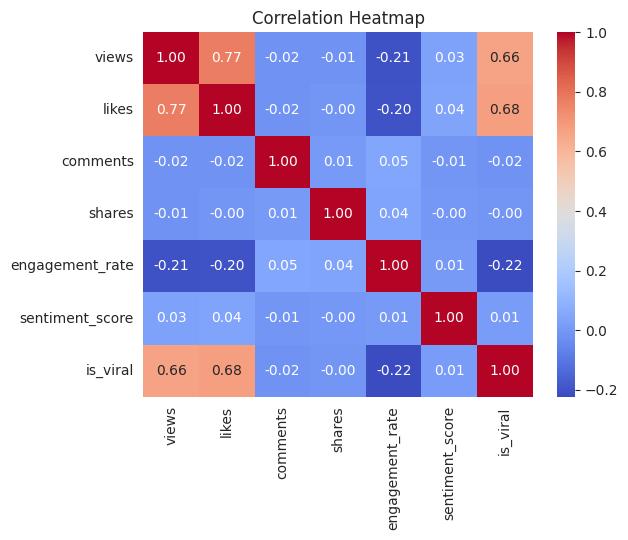

In [ ]:
corr = df[['views','likes','comments','shares','engagement_rate','sentiment_score','is_viral']].corr()
plt.figure(figsize=(6.5,5.5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 3. Feature Engineering



In [ ]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'])
df['post_month'] = df['post_datetime'].dt.month
df['post_dayofweek'] = df['post_datetime'].dt.dayofweek
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()))

# Flag presence of the 8 most common hashtags
all_tags = df['hashtags'].str.split(expand=True).stack()
top_tags = all_tags.value_counts().head(8).index.tolist()
print("Top hashtags:", top_tags)
for t in top_tags:
    col = 'tag_' + t.replace('#','')
    df[col] = df['hashtags'].apply(lambda x, t=t: 1 if t in str(x).split() else 0)

df.head()

Top hashtags: ['#trending', '#music', '#viral', '#funny', '#news', '#ai', '#tech', '#fyp']


,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral,post_month,post_dayofweek,hashtag_count,tag_trending,tag_music,tag_viral,tag_funny,tag_news,tag_ai,tag_tech,tag_fyp
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1,12,1,3,0,1,0,1,0,0,1,0
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1,10,6,5,1,0,0,1,1,1,0,1
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0,5,4,2,0,0,0,0,1,1,0,0
3,SM_100003,X,text,Politics,ur,US,2024-08-04,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1,8,6,2,0,0,0,1,0,1,0,0
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1,3,3,5,0,0,1,1,1,1,0,1


## 4. Preprocessing Pipeline

In [ ]:
target = 'is_viral'
categorical = ['platform','content_type','topic','language','region']
numeric = ['sentiment_score','hashtag_count','post_month','post_dayofweek'] + \
          [c for c in df.columns if c.startswith('tag_')]

X = df[categorical + numeric]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1600, 17) Test: (400, 17)


## 5. Model Comparison (Cross-Validation)



In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=42),
    'SVM (RBF)': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    results.append({'model': name, 'cv_f1_mean': scores.mean(), 'cv_f1_std': scores.std()})

res_df = pd.DataFrame(results).sort_values('cv_f1_mean', ascending=False)
res_df

,model,cv_f1_mean,cv_f1_std
3,SVM (RBF),0.821791,0.002536
1,Random Forest,0.819988,0.003531
0,Logistic Regression,0.819537,0.003925
2,Hist Gradient Boosting,0.779067,0.005897
4,XGBoost,0.756378,0.014716


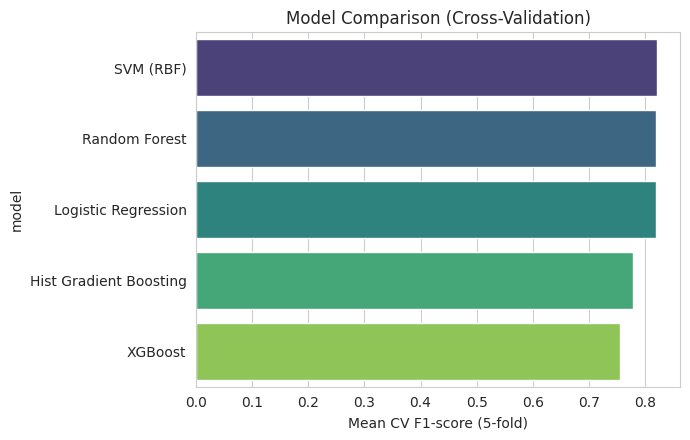

In [ ]:
plt.figure(figsize=(7,4.5))
sns.barplot(data=res_df, x='cv_f1_mean', y='model', hue='model', palette='viridis', legend=False)
plt.xlabel('Mean CV F1-score (5-fold)')
plt.title('Model Comparison (Cross-Validation)')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning (RandomizedSearchCV)

In [ ]:
pipe = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42))])

param_dist = {
    'clf__n_estimators': [200,300,400,500],
    'clf__max_depth': [None,6,10,14,20],
    'clf__min_samples_split': [2,5,10],
    'clf__min_samples_leaf': [1,2,4],
    'clf__max_features': ['sqrt','log2',None]
}
search = RandomizedSearchCV(pipe, param_dist, n_iter=25, scoring='f1', cv=cv,
                             random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)
print("Best CV F1:", round(search.best_score_, 4))
best = search.best_estimator_

Best parameters: {'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 6}
Best CV F1: 0.823


## 7. Evaluation on the Held-Out Test Set

In [ ]:
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:,1]

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1-score': f1_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\nBaseline (always predict majority class 'Viral'):",
      round((y_test==1).mean(), 4))

Accuracy: 0.7000
F1-score: 0.8235
Precision: 0.7000
Recall: 1.0000
ROC-AUC: 0.4210

Baseline (always predict majority class 'Viral'): 0.7


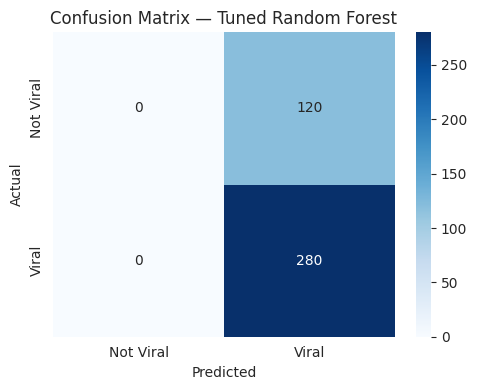

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Viral','Viral'], yticklabels=['Not Viral','Viral'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Tuned Random Forest')
plt.tight_layout()
plt.show()

<Figure size 500x450 with 0 Axes>

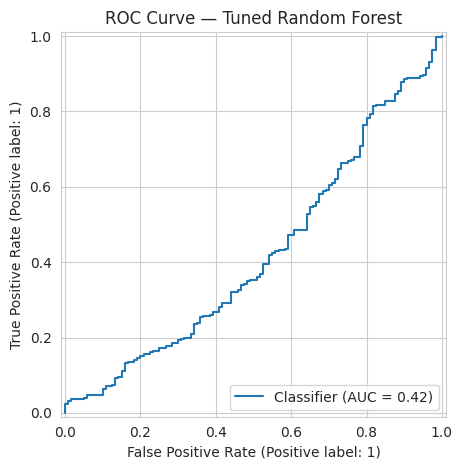

In [ ]:
plt.figure(figsize=(5,4.5))
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve — Tuned Random Forest')
plt.tight_layout()
plt.show()

## 8. Explainability: Feature Importance and SHAP



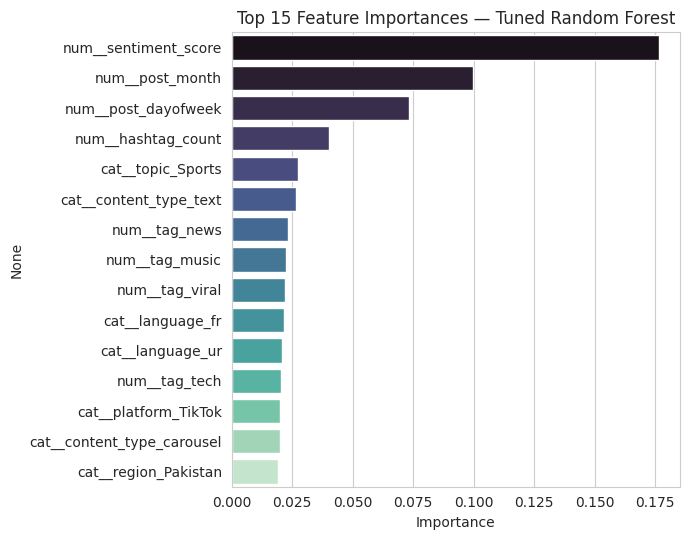

In [ ]:
feat_names = best.named_steps['prep'].get_feature_names_out()
importances = best.named_steps['clf'].feature_importances_
fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(7,5.5))
sns.barplot(x=fi.values, y=fi.index, hue=fi.index, palette='mako', legend=False)
plt.title('Top 15 Feature Importances — Tuned Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

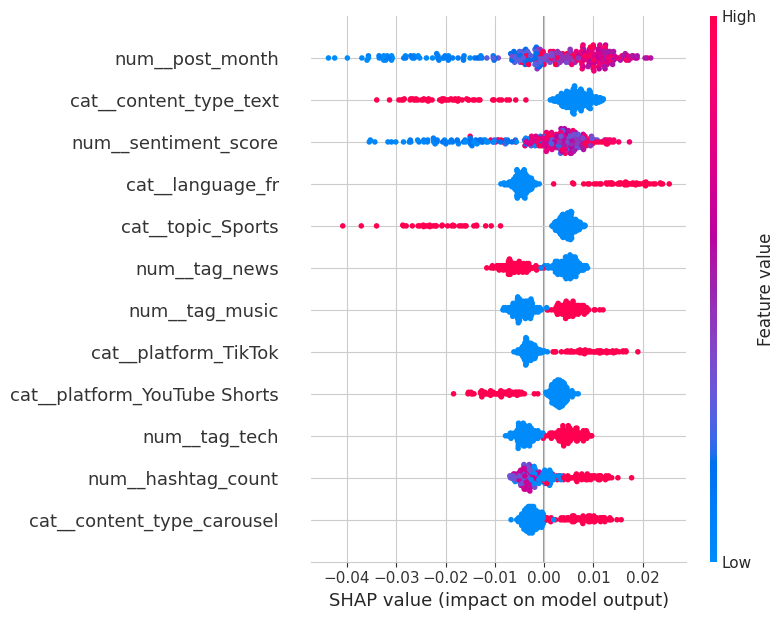

In [ ]:
X_test_transformed = best.named_steps['prep'].transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()

explainer = shap.TreeExplainer(best.named_steps['clf'])
shap_values = explainer.shap_values(X_test_transformed[:300])
if isinstance(shap_values, list):
    sv = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

shap.summary_plot(sv, X_test_transformed[:300], feature_names=feat_names, max_display=12)

## 9. Deployment (Prediction Interface)



in this code,
The **sentiment score** is a numerical value that quantifies the emotional tone of a piece of content, typically ranging from -1 to 1:

*   **-1:** Represents a very **negative** sentiment.
*   **0:** Represents a **neutral** sentiment.
*   **1:** Represents a very **positive** sentiment.

This score is used to understand the emotional leaning of a post's content, which can sometimes influence its virality. For instance, a score of `0.8` indicates a strongly positive tone, while `-0.2` suggests a slightly negative tone.


In [ ]:

platform_input = input("Enter the platform (e.g., 'Instagram', 'TikTok', 'X', 'YouTube Shorts'): ")
content_type_input = input("Enter the content type (e.g., 'image', 'video', 'text', 'carousel'): ")
topic_input = input("Enter the topic (e.g., 'Lifestyle', 'Technology', 'Sports', 'Education', 'Entertainment', 'Politics'): ")
language_input = input("Enter the language (e.g., 'en', 'es', 'hi', 'fr', 'ur'): ")
region_input = input("Enter the region (e.g., 'US', 'UK', 'India', 'Brazil', 'Pakistan'): ")
sentiment_score_input = float(input("Enter the sentiment score (e.g., 0.8, -0.2): "))
hashtag_count_input = int(input("Enter the number of hashtags (e.g., 5): "))
post_month_input = int(input("Enter the post month (1-12, e.g., 7 for July): "))
post_dayofweek_input = int(input("Enter the post day of the week (0=Monday, 6=Sunday, e.g., 3 for Wednesday): "))

tag_flags_input = {
    'tag_trending': 0, 'tag_music': 0, 'tag_viral': 0, 'tag_funny': 0,
    'tag_news': 0, 'tag_ai': 0, 'tag_tech': 0, 'tag_fyp': 0
}


prediction_output = predict_virality(
    platform=platform_input,
    content_type=content_type_input,
    topic=topic_input,
    language=language_input,
    region=region_input,
    sentiment_score=sentiment_score_input,
    hashtag_count=hashtag_count_input,
    post_month=post_month_input,
    post_dayofweek=post_dayofweek_input,
    tag_flags=tag_flags_input
)

print(prediction_output)

Enter the platform (e.g., 'Instagram', 'TikTok', 'X', 'YouTube Shorts'): x
Enter the content type (e.g., 'image', 'video', 'text', 'carousel'): video
Enter the topic (e.g., 'Lifestyle', 'Technology', 'Sports', 'Education', 'Entertainment', 'Politics'): education
Enter the language (e.g., 'en', 'es', 'hi', 'fr', 'ur'): hi
Enter the region (e.g., 'US', 'UK', 'India', 'Brazil', 'Pakistan'): india
Enter the sentiment score (e.g., 0.8, -0.2): 1
Enter the number of hashtags (e.g., 5): 2
Enter the post month (1-12, e.g., 7 for July): 5
Enter the post day of the week (0=Monday, 6=Sunday, e.g., 3 for Wednesday): 5
This probability of this post to be viral is 0.6838 on x
